## 1. 라이브러리 준비

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

## 2. 전처리

In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

## 3. 데이터셋 불러오기

In [3]:
train_dataset = datasets.CIFAR100('./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)

classes = train_dataset.classes

## 4. 데이터로더 준비

In [4]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, 
                          num_workers=4, pin_memory=False, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, 
                          num_workers=4, pin_memory=False, persistent_workers=True)

## 5. 모델 설계

In [5]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 2: 레이어 2겹
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 3: 레이어 2겹
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # 분류기 (GAP 적용으로 파라미터 다이어트 및 과적합 방지)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CIFAR_CNN().to(device)

## 6. 모델 학습 및 최적화

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset) * 100

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset) * 100

## 7. 학습 하이퍼파라미터 및 최적화

In [7]:
EPOCHS = 100
best_acc = 0

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

## 8. 모델 학습 실행 및 결과 저장

In [8]:
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step()
    
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar100_model.pth')

print(f"\n최고 테스트 정확도: {best_acc:.2f}%")

Epoch  1/100 | Train Loss: 4.0341 Acc: 8.0% | Test Loss: 3.5966 Acc: 13.9%
Epoch  2/100 | Train Loss: 3.4562 Acc: 15.9% | Test Loss: 3.1972 Acc: 20.4%
Epoch  3/100 | Train Loss: 3.1189 Acc: 21.6% | Test Loss: 2.8419 Acc: 27.6%
Epoch  4/100 | Train Loss: 2.9164 Acc: 25.7% | Test Loss: 2.8110 Acc: 27.5%
Epoch  5/100 | Train Loss: 2.7566 Acc: 29.0% | Test Loss: 2.7236 Acc: 29.7%
Epoch  6/100 | Train Loss: 2.6293 Acc: 31.5% | Test Loss: 2.5529 Acc: 33.6%
Epoch  7/100 | Train Loss: 2.5268 Acc: 33.4% | Test Loss: 2.2983 Acc: 37.9%
Epoch  8/100 | Train Loss: 2.4402 Acc: 35.7% | Test Loss: 2.2802 Acc: 38.6%
Epoch  9/100 | Train Loss: 2.3667 Acc: 37.3% | Test Loss: 2.3284 Acc: 38.1%
Epoch 10/100 | Train Loss: 2.3051 Acc: 38.5% | Test Loss: 2.1188 Acc: 42.8%
Epoch 11/100 | Train Loss: 2.2397 Acc: 40.0% | Test Loss: 2.1728 Acc: 41.6%
Epoch 12/100 | Train Loss: 2.1885 Acc: 41.1% | Test Loss: 2.0941 Acc: 43.4%
Epoch 13/100 | Train Loss: 2.1495 Acc: 41.9% | Test Loss: 2.0815 Acc: 44.1%
Epoch 14/100 

## 9. 모델 해석 및 다각적 성능 분석

### 9.1 합성곱 필터 시각화 및 가중치 분석

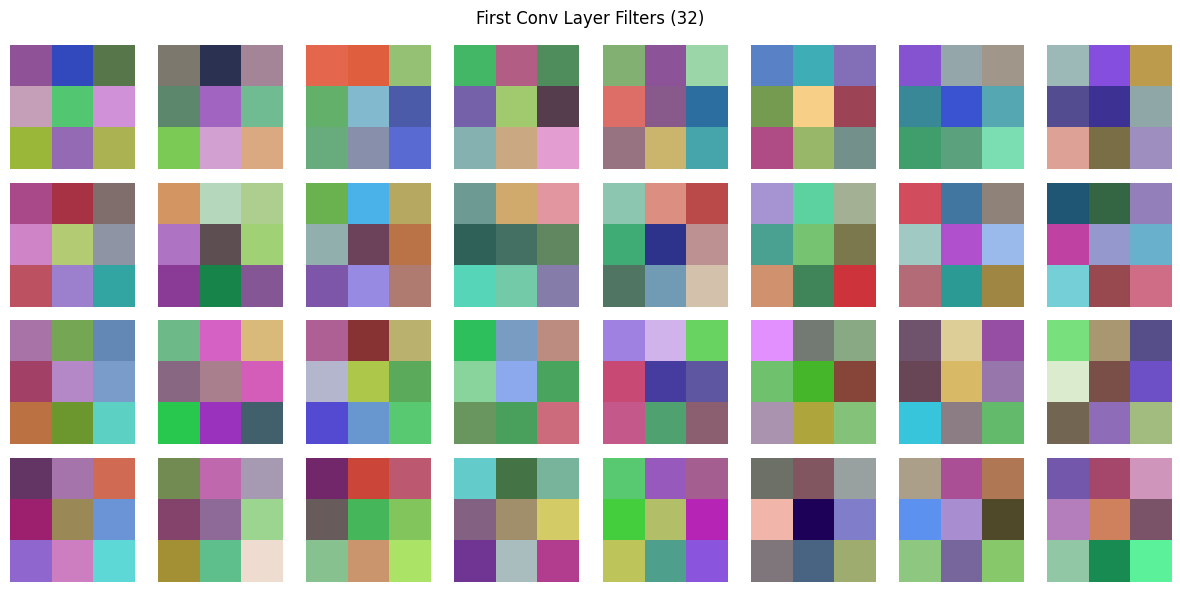

In [9]:
weights = model.block1[0].weight.data.cpu()
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        filt = weights[i].permute(1, 2, 0).numpy()
        ax.imshow(filt)
    ax.axis('off')
plt.suptitle("First Conv Layer Filters (32)", fontsize=12)
plt.tight_layout()
plt.show()

### 9.2 특징맵 시각화

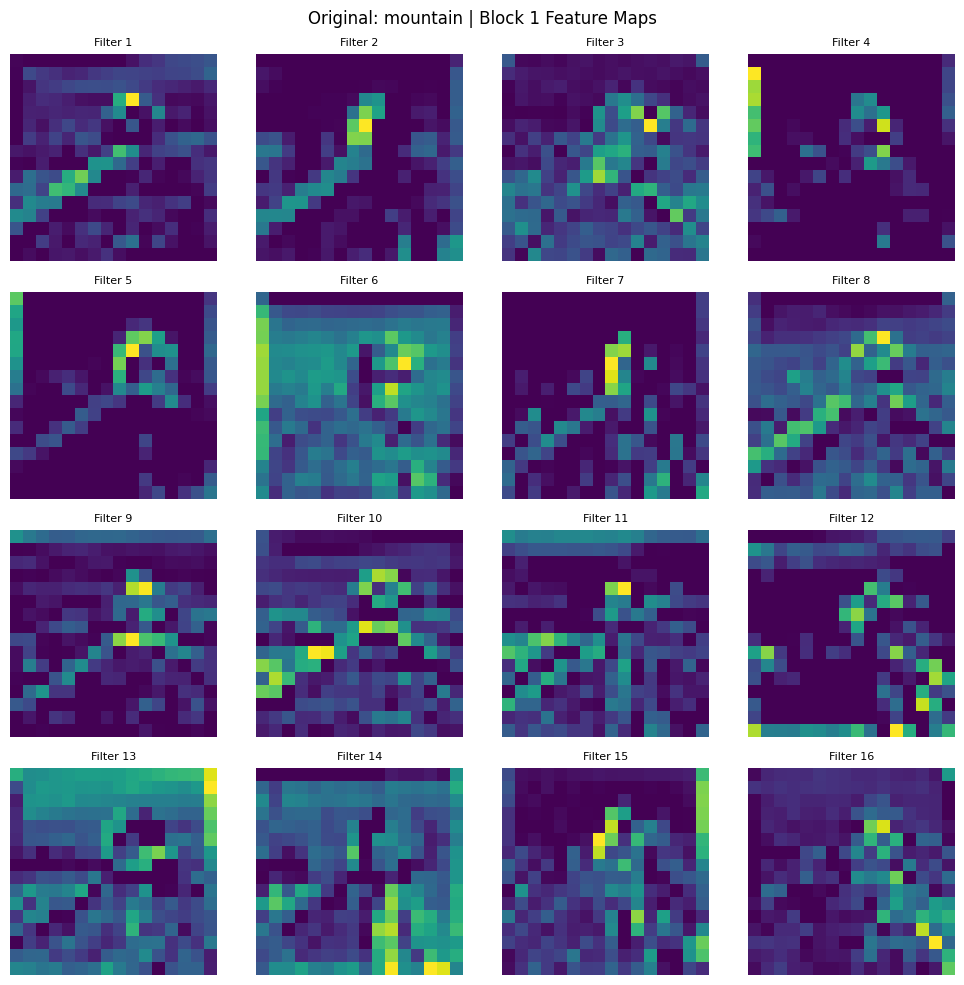

In [10]:
image, label = test_dataset[0]
image_tensor = image.unsqueeze(0).to(device)

feature_maps = {}
def hook_fn(module, input, output):
    feature_maps['block1'] = output.detach().cpu()

hook = model.block1.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    _ = model(image_tensor)

hook.remove()

fmaps = feature_maps['block1'][0]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i].numpy(), cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis('off')

plt.suptitle(f"Original: {classes[label]} | Block 1 Feature Maps", fontsize=12)
plt.tight_layout()
plt.show()

### 9.3 혼동 행렬 분석을 통한 클래스별 분류 성능 평가

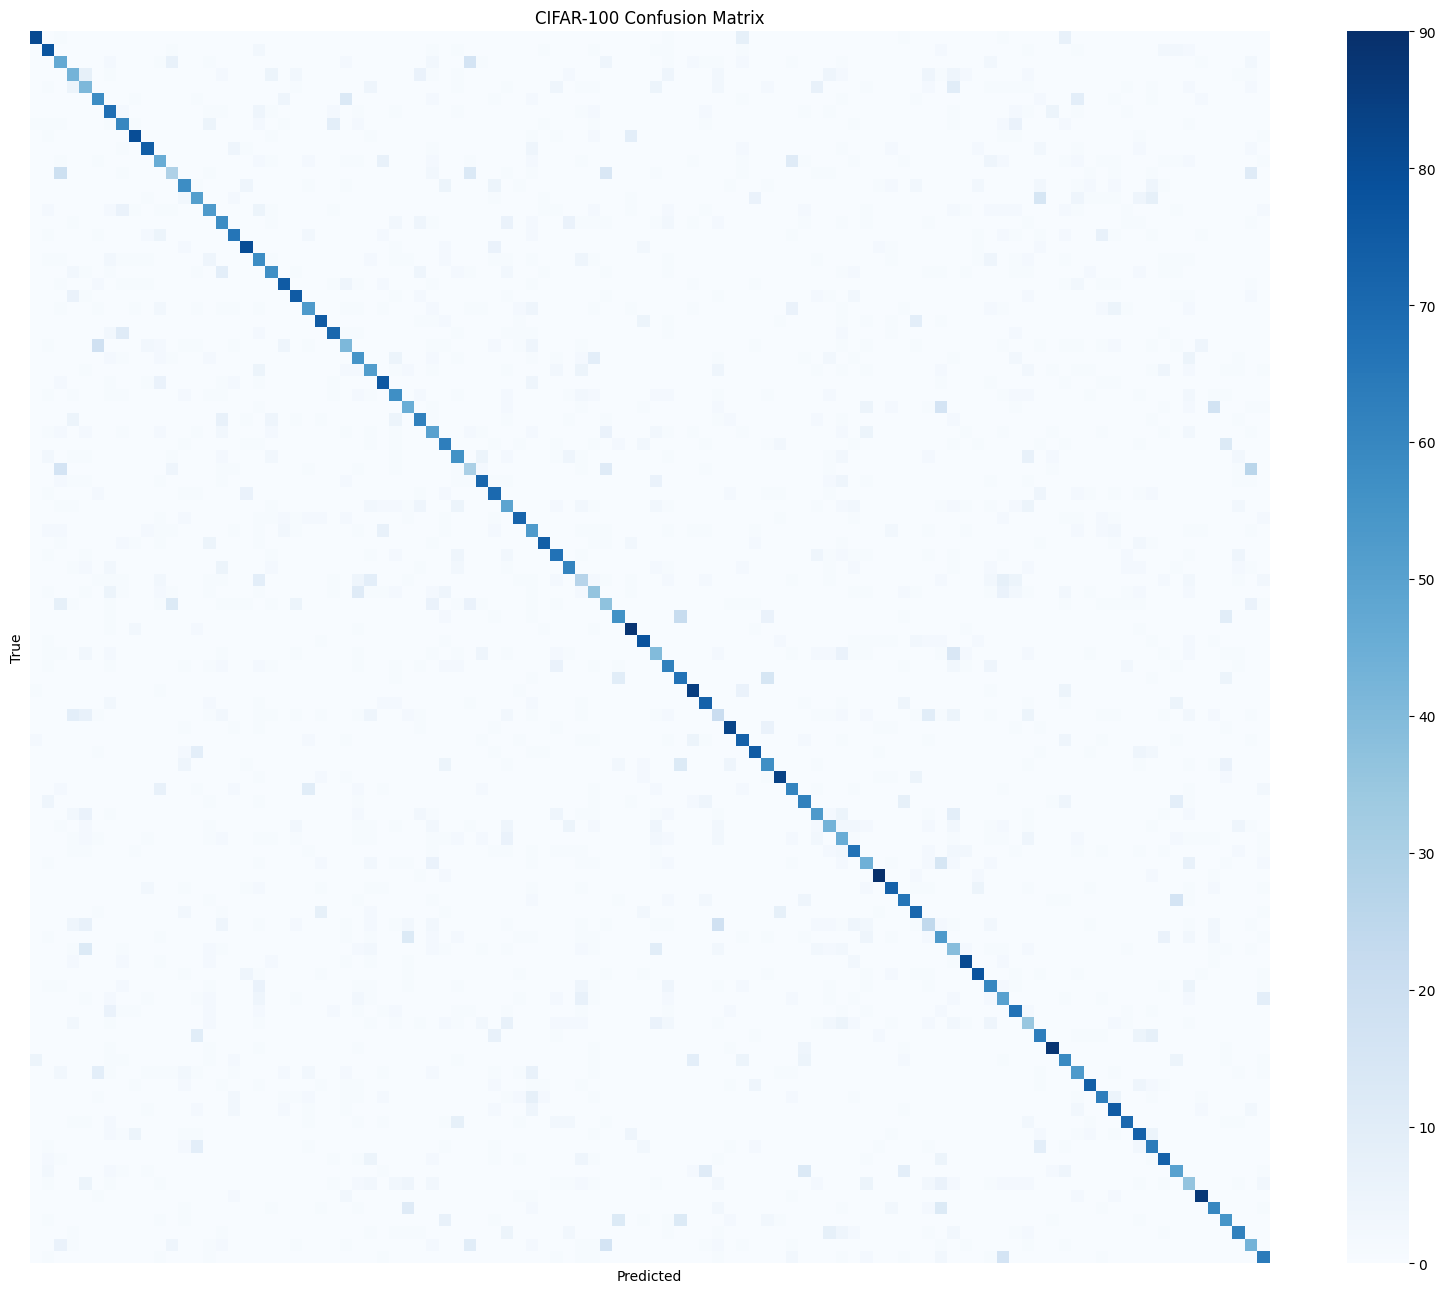

In [11]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CIFAR-100 Confusion Matrix')
plt.show()

## 10. 테스트 데이터셋 기반 무작위 이미지 추론 검증

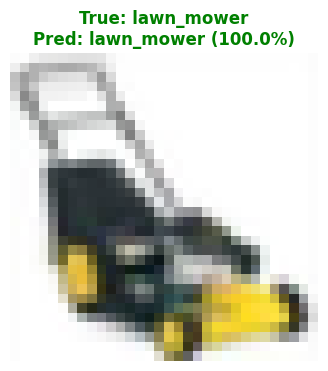

🎉 정답입니다! (실제: lawn_mower / 예측: lawn_mower)


In [15]:
import random
def predict_random_cifar_image(model, dataset, device, classes):
    model.eval()

    idx = random.randint(0, len(dataset) - 1)
    image_tensor, true_label_idx = dataset[idx]
    true_class = classes[true_label_idx]

    img_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_input)
        probabilities = F.softmax(output[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, dim=0)

    predicted_class = classes[predicted_idx.item()]
    confidence_score = confidence.item() * 100

    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
    img_show = image_tensor.cpu() * std + mean

    img_show = img_show.clamp(0, 1).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)

    title_color = 'green' if true_class == predicted_class else 'red'
    plt.title(f"True: {true_class}\nPred: {predicted_class} ({confidence_score:.1f}%)",
              color=title_color, fontweight='bold')
    plt.axis('off')
    plt.show()

    if true_class == predicted_class:
        print(f"🎉 정답입니다! (실제: {true_class} / 예측: {predicted_class})")
    else:
        print(f"😢 틀렸습니다. (실제: {true_class} / 예측: {predicted_class})")

predict_random_cifar_image(model, test_dataset, device, classes)